# Nonlinear Elastica with Parametrized Imperfection

This notebook computes the equilibria of an inextensible, unshearable planar beam (the Euler elastica), clamped at one end and loaded by a dead force at the other. The quasi-static problem is posed as the minimization of the potential energy and solved by the finite element method with [FEniCSx](https://fenicsproject.org) (dolfinx 0.11).

The imperfection is a constant natural curvature $k_0$, treated as a parameter.

The notebook contains:
- the tip deflection of a cantilever under a transverse tip load, compared with linear beam theory;
- the critical load of the clamped-free beam, computed from the second variation of the energy;
- the post-buckling response of the beam under axial compression, with an imperfection.

## Mathematical model

The beam has length $L$ and bending stiffness $EI$. Its configuration is described by:
- $\underline{x}(s) = x(s)\,\underline{e}_1 + y(s)\,\underline{e}_2$, the position of the centerline, with $s \in [0, L]$ the arc-length;
- $\theta(s)$, the angle between the tangent to the centerline and $\underline{e}_1$.

Inextensibility and the absence of shear strain read
$$
\underline{x}'(s) = \cos\theta(s)\,\underline{e}_1 + \sin\theta(s)\,\underline{e}_2 .
$$

The beam is clamped at $s=0$: $x(0) = y(0) = 0$ and $\theta(0) = 0$. The end $s = L$ is free and carries the dead load $\underline{F} = F_x\,\underline{e}_1 + F_y\,\underline{e}_2$.

The potential energy is the bending energy minus the work of the load:
$$
\mathcal{E}(\underline{x}, \theta) = \frac{EI}{2}\int_0^L \big(\theta'(s) - k_0\big)^2\,ds \;-\; F_x\,x(L) - F_y\,y(L).
$$

### Reduction to the angle

The kinematic constraint and the clamped conditions give the position explicitly as a function of the angle:
$$
x(L) = \int_0^L \cos\theta(s)\,ds, \qquad y(L) = \int_0^L \sin\theta(s)\,ds .
$$
Substituting these expressions, the energy becomes a functional of $\theta$ alone:
$$
\mathcal{E}(\theta) = \int_0^L \Big[\frac{EI}{2}\big(\theta'(s) - k_0\big)^2 - F_x\cos\theta(s) - F_y\sin\theta(s)\Big]\,ds ,
$$
to be minimized over the angles such that $\theta(0) = 0$. The constraint has disappeared: the problem is an unconstrained minimization with one essential boundary condition.

The first variation in the direction $\hat\theta$, with $\hat\theta(0) = 0$, is
$$
\mathcal{E}'(\theta)(\hat\theta) = \int_0^L \Big[EI\big(\theta'(s) - k_0\big)\,\hat\theta'(s) + \big(F_x\sin\theta(s) - F_y\cos\theta(s)\big)\,\hat\theta(s)\Big]\,ds .
$$
It vanishes for every $\hat\theta$ if and only if $\theta$ solves the Euler-Lagrange equation and the natural boundary condition
$$
EI\,\theta''(s) = F_x\sin\theta(s) - F_y\cos\theta(s), \qquad \theta'(L) = k_0 .
$$

## Numerical method

The angle is approximated by continuous piecewise quadratic finite elements on a uniform mesh of $[0, L]$. The weak form above is the residual; its derivative, the second variation of the energy, is the Jacobian. [UFL](https://github.com/FEniCS/ufl) derives both symbolically from the expression of the energy (`ufl.derivative`), so that only the energy is written by hand.

The nonlinear equations are solved by Newton's method (PETSc SNES) with a direct linear solver. The loads $F_x$, $F_y$ and the imperfection $k_0$ are `fem.Constant` objects: their values change between solves without recompiling the forms. Each solve starts from the previous solution, which follows the equilibrium branch by continuation in the load.

The tip position is computed by assembling $\int_0^L\cos\theta\,ds$ and $\int_0^L\sin\theta\,ds$. The deformed shape is obtained by integrating $\underline{x}' = \cos\theta\,\underline{e}_1 + \sin\theta\,\underline{e}_2$ along the nodes.

References:
- B. Audoly, Y. Pomeau (2010). *Elasticity and Geometry*, Oxford University Press.
- J.-J. Marigo, MEC 430, class notes, École Polytechnique.
- FEniCSx documentation and tutorial: https://docs.fenicsproject.org, https://jsdokken.com/dolfinx-tutorial/

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from mpi4py import MPI
from petsc4py import PETSc
from slepc4py import SLEPc
import ufl
import dolfinx
from dolfinx import mesh, fem
from dolfinx.fem.petsc import NonlinearProblem, assemble_matrix

print(f"dolfinx {dolfinx.__version__}")

dolfinx 0.11.0


In [2]:
# Parameters
L = 1.0
EI = 1.0
N = 100  # number of elements
F0 = EI / L**2  # force scale

domain = mesh.create_interval(MPI.COMM_WORLD, N, [0.0, L])
V = fem.functionspace(domain, ("Lagrange", 2))

theta = fem.Function(V, name="theta")
Fx = fem.Constant(domain, PETSc.ScalarType(0.0))  # horizontal tip force
Fy = fem.Constant(domain, PETSc.ScalarType(0.0))  # vertical tip force
k0 = fem.Constant(domain, PETSc.ScalarType(0.0))  # natural curvature

# Potential energy, residual and Jacobian
energy = (0.5 * EI * (theta.dx(0) - k0) ** 2 - Fx * ufl.cos(theta) - Fy * ufl.sin(theta)) * ufl.dx
theta_hat = ufl.TestFunction(V)
dtheta = ufl.TrialFunction(V)
residual = ufl.derivative(energy, theta, theta_hat)
jacobian = ufl.derivative(residual, theta, dtheta)

# Clamped end: theta(0) = 0
clamped_dofs = fem.locate_dofs_geometrical(V, lambda s: np.isclose(s[0], 0.0))
bc = fem.dirichletbc(PETSc.ScalarType(0.0), clamped_dofs, V)

problem = NonlinearProblem(
    residual, theta, bcs=[bc], J=jacobian,
    petsc_options_prefix="elastica_",
    petsc_options={
        "snes_type": "newtonls",
        "snes_linesearch_type": "basic",
        "snes_rtol": 1e-10,
        "snes_atol": 1e-12,
        "snes_max_it": 50,
        "ksp_type": "preonly",
        "pc_type": "lu",
    },
)

# Tip position as functionals of theta
x_tip_form = fem.form(ufl.cos(theta) * ufl.dx)
y_tip_form = fem.form(ufl.sin(theta) * ufl.dx)

# Nodes sorted by arc-length, to reconstruct the deformed shape
s_dofs = V.tabulate_dof_coordinates()[:, 0]
order = np.argsort(s_dofs)
s_nodes = s_dofs[order]


def solve_equilibrium():
    """Solve for the current values of Fx, Fy, k0, starting from the current theta."""
    problem.solve()
    snes = problem.solver
    reason = snes.getConvergedReason()
    if reason <= 0:
        raise RuntimeError(f"Newton did not converge (reason {reason})")
    return snes.getIterationNumber()


def shape():
    """Centerline (x, y) at the nodes, by trapezoidal integration of x' = cos theta, y' = sin theta."""
    th = theta.x.array[order]
    ds = np.diff(s_nodes)
    x = np.concatenate([[0.0], np.cumsum(0.5 * ds * (np.cos(th[1:]) + np.cos(th[:-1])))])
    y = np.concatenate([[0.0], np.cumsum(0.5 * ds * (np.sin(th[1:]) + np.sin(th[:-1])))])
    return x, y


def tip():
    """Tip position x(L), y(L) and tip rotation theta(L)."""
    return fem.assemble_scalar(x_tip_form), fem.assemble_scalar(y_tip_form), theta.x.array[order][-1]

## Example 1: vertical tip load, no imperfection

A vertical force $F_y$ is applied at the free end, with $F_x = 0$ and $k_0 = 0$. Linear Euler-Bernoulli theory predicts the tip deflection
$$
y^{\text{lin}}(L) = \frac{F_y L^3}{3EI},
$$
valid for small rotations. The nonlinear solution departs from it as the load increases.

In [3]:
load_values = np.linspace(0, 4, 50) * F0
Fx.value, k0.value = 0.0, 0.0
theta.x.array[:] = 0.0

shapes, tip_deflections, tip_rotations = [], [], []
for Fy_val in load_values:
    Fy.value = Fy_val
    its = solve_equilibrium()
    xL, yL, thL = tip()
    shapes.append(shape())
    tip_deflections.append(yL)
    tip_rotations.append(thL)
    print(f"Fy/F0 = {Fy_val / F0:.3f} | Newton iterations = {its} | y(L)/L = {yL / L:.4f}")

Fy/F0 = 0.000 | Newton iterations = 0 | y(L)/L = 0.0000
Fy/F0 = 0.082 | Newton iterations = 3 | y(L)/L = 0.0272
Fy/F0 = 0.163 | Newton iterations = 3 | y(L)/L = 0.0543
Fy/F0 = 0.245 | Newton iterations = 3 | y(L)/L = 0.0811
Fy/F0 = 0.327 | Newton iterations = 3 | y(L)/L = 0.1075
Fy/F0 = 0.408 | Newton iterations = 3 | y(L)/L = 0.1336
Fy/F0 = 0.490 | Newton iterations = 3 | y(L)/L = 0.1590
Fy/F0 = 0.571 | Newton iterations = 3 | y(L)/L = 0.1838
Fy/F0 = 0.653 | Newton iterations = 3 | y(L)/L = 0.2079
Fy/F0 = 0.735 | Newton iterations = 3 | y(L)/L = 0.2313
Fy/F0 = 0.816 | Newton iterations = 3 | y(L)/L = 0.2539
Fy/F0 = 0.898 | Newton iterations = 3 | y(L)/L = 0.2757
Fy/F0 = 0.980 | Newton iterations = 3 | y(L)/L = 0.2966
Fy/F0 = 1.061 | Newton iterations = 3 | y(L)/L = 0.3167
Fy/F0 = 1.143 | Newton iterations = 3 | y(L)/L = 0.3360
Fy/F0 = 1.224 | Newton iterations = 3 | y(L)/L = 0.3545
Fy/F0 = 1.306 | Newton iterations = 3 | y(L)/L = 0.3721
Fy/F0 = 1.388 | Newton iterations = 3 | y(L)/L =

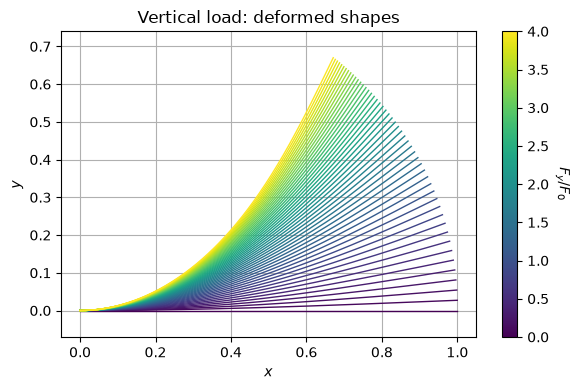

In [4]:
cmap = cm.viridis
norm = mcolors.Normalize(vmin=load_values[0] / F0, vmax=load_values[-1] / F0)
fig, ax = plt.subplots(figsize=(6, 4))
for Fy_val, (xv, yv) in zip(load_values, shapes):
    ax.plot(xv, yv, color=cmap(norm(Fy_val / F0)), linewidth=1)
cbar = fig.colorbar(cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax)
cbar.set_label("$F_y / F_0$", rotation=270, labelpad=15)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("Vertical load: deformed shapes")
ax.axis("equal")
ax.grid(True)
plt.tight_layout()
plt.show()

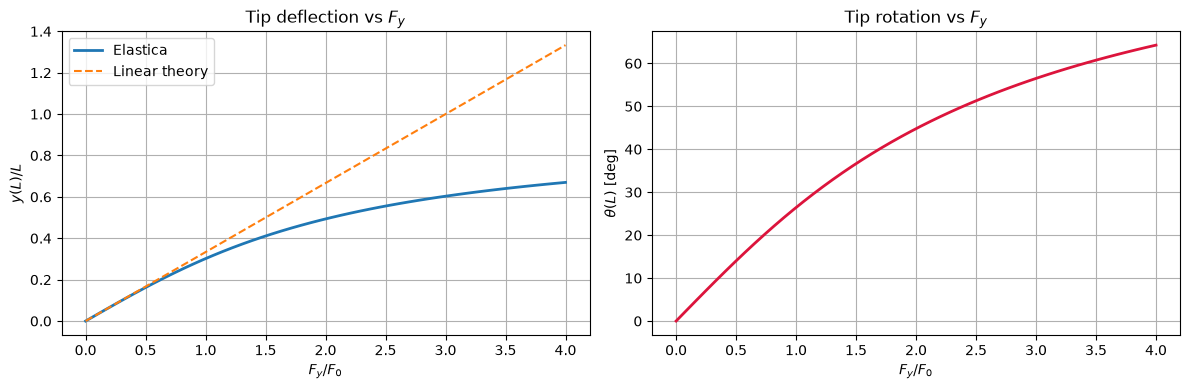

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(load_values / F0, np.array(tip_deflections) / L, lw=2, label="Elastica")
ax[0].plot(load_values / F0, load_values * L**2 / (3 * EI), "--", label="Linear theory")
ax[0].set_title("Tip deflection vs $F_y$")
ax[0].set_xlabel("$F_y / F_0$")
ax[0].set_ylabel("$y(L) / L$")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(load_values / F0, np.rad2deg(tip_rotations), lw=2, color="crimson")
ax[1].set_title("Tip rotation vs $F_y$")
ax[1].set_xlabel("$F_y / F_0$")
ax[1].set_ylabel(r"$\theta(L)$ [deg]")
ax[1].grid(True)
plt.tight_layout()
plt.show()

## Critical load of the clamped-free beam

Under a compressive axial load $F_x = -P$, with $F_y = 0$ and $k_0 = 0$, the straight configuration $\theta = 0$ is an equilibrium for every $P$. Its second variation is
$$
\mathcal{E}''(0)(\hat\theta, \hat\theta) = \int_0^L \Big[EI\,\hat\theta'(s)^2 - P\,\hat\theta(s)^2\Big]\,ds .
$$
It is positive definite as long as $P$ is smaller than the smallest eigenvalue of the generalized eigenvalue problem
$$
\int_0^L EI\,\hat\theta'(s)\,v'(s)\,ds = P \int_0^L \hat\theta(s)\,v(s)\,ds \qquad \text{for all } v \text{ with } v(0) = 0 .
$$
Its exact eigenvalues are $P_n = (2n-1)^2\,\pi^2 EI / (4L^2)$; the smallest one is the Euler critical load of the clamped-free beam,
$$
F_{\text{crit}} = \frac{\pi^2 EI}{4L^2} .
$$
The finite element eigenvalues are computed with SLEPc.

In [6]:
F_crit = np.pi**2 * EI / (4 * L**2)

K = assemble_matrix(fem.form(EI * dtheta.dx(0) * theta_hat.dx(0) * ufl.dx), bcs=[bc])  # 1 on the clamped diagonal
K.assemble()
M = assemble_matrix(fem.form(dtheta * theta_hat * ufl.dx), bcs=[bc], diag=0.0)  # 0 on the clamped diagonal
M.assemble()

eps = SLEPc.EPS().create(domain.comm)
eps.setOperators(K, M)
eps.setProblemType(SLEPc.EPS.ProblemType.GHEP)
eps.setDimensions(4)
eps.setTarget(0.0)
eps.setWhichEigenpairs(SLEPc.EPS.Which.TARGET_MAGNITUDE)
st = eps.getST()
st.setType(SLEPc.ST.Type.SINVERT)
st.getKSP().setType("preonly")
st.getKSP().getPC().setType("lu")
eps.solve()

P_num = sorted(eps.getEigenvalue(i).real for i in range(eps.getConverged()))[:4]
for n, P in enumerate(P_num, start=1):
    print(f"n = {n}: P_n / F_crit = {P / F_crit:.6f}   (exact: {(2 * n - 1) ** 2})")

n = 1: P_n / F_crit = 1.000000   (exact: 1)
n = 2: P_n / F_crit = 9.000000   (exact: 9)
n = 3: P_n / F_crit = 25.000001   (exact: 25)
n = 4: P_n / F_crit = 49.000010   (exact: 49)


## Example 2: axial compression with imperfection

A compressive force $F_x = -P$ is applied at the free end, with $F_y = 0$ and the natural curvature $k_0 = 0.02\,\pi/L$. The load is increased up to $50\,F_{\text{crit}}$. Without imperfection, Newton's method stays on the straight branch $\theta = 0$, which is unstable beyond $F_{\text{crit}}$. The imperfection breaks the symmetry: the beam deflects from the start, slowly below $F_{\text{crit}}$ and markedly above.

In [7]:
# Load steps: fine around the bifurcation, geometric up to large loads
compression_values = F_crit * np.concatenate([np.linspace(0, 3, 61), np.geomspace(3, 50, 40)[1:]])
Fy.value, k0.value = 0.0, 0.02 * np.pi / L
theta.x.array[:] = 0.0

shapes, theta_profiles, tip_deflections, tip_rotations = [], [], [], []
for P in compression_values:
    Fx.value = -P
    its = solve_equilibrium()
    xL, yL, thL = tip()
    shapes.append(shape())
    theta_profiles.append(theta.x.array[order].copy())
    tip_deflections.append(yL)
    tip_rotations.append(thL)
    print(f"P/F_crit = {P / F_crit:.3f} | Newton iterations = {its} | y(L)/L = {yL / L:.4f}")

P/F_crit = 0.000 | Newton iterations = 1 | y(L)/L = 0.0314
P/F_crit = 0.050 | Newton iterations = 2 | y(L)/L = 0.0331
P/F_crit = 0.100 | Newton iterations = 2 | y(L)/L = 0.0350
P/F_crit = 0.150 | Newton iterations = 2 | y(L)/L = 0.0371
P/F_crit = 0.200 | Newton iterations = 2 | y(L)/L = 0.0395
P/F_crit = 0.250 | Newton iterations = 2 | y(L)/L = 0.0422
P/F_crit = 0.300 | Newton iterations = 2 | y(L)/L = 0.0452
P/F_crit = 0.350 | Newton iterations = 2 | y(L)/L = 0.0488
P/F_crit = 0.400 | Newton iterations = 2 | y(L)/L = 0.0529
P/F_crit = 0.450 | Newton iterations = 2 | y(L)/L = 0.0578
P/F_crit = 0.500 | Newton iterations = 2 | y(L)/L = 0.0636
P/F_crit = 0.550 | Newton iterations = 2 | y(L)/L = 0.0707
P/F_crit = 0.600 | Newton iterations = 2 | y(L)/L = 0.0796
P/F_crit = 0.650 | Newton iterations = 3 | y(L)/L = 0.0909
P/F_crit = 0.700 | Newton iterations = 3 | y(L)/L = 0.1057
P/F_crit = 0.750 | Newton iterations = 3 | y(L)/L = 0.1260
P/F_crit = 0.800 | Newton iterations = 3 | y(L)/L = 0.15

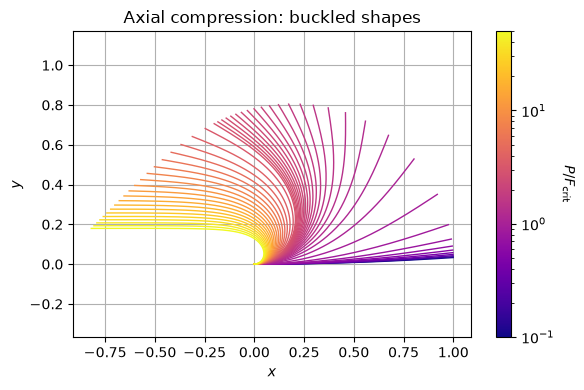

In [8]:
cmap = cm.plasma
norm = mcolors.LogNorm(vmin=0.1, vmax=compression_values[-1] / F_crit)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(1, len(shapes), 2):
    xb, yb = shapes[i]
    ax.plot(xb, yb, color=cmap(norm(compression_values[i] / F_crit)), linewidth=1)
cbar = fig.colorbar(cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax)
cbar.set_label(r"$P / F_{\mathrm{crit}}$", rotation=270, labelpad=15)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("Axial compression: buckled shapes")
ax.axis("equal")
ax.grid(True)
plt.tight_layout()
plt.show()

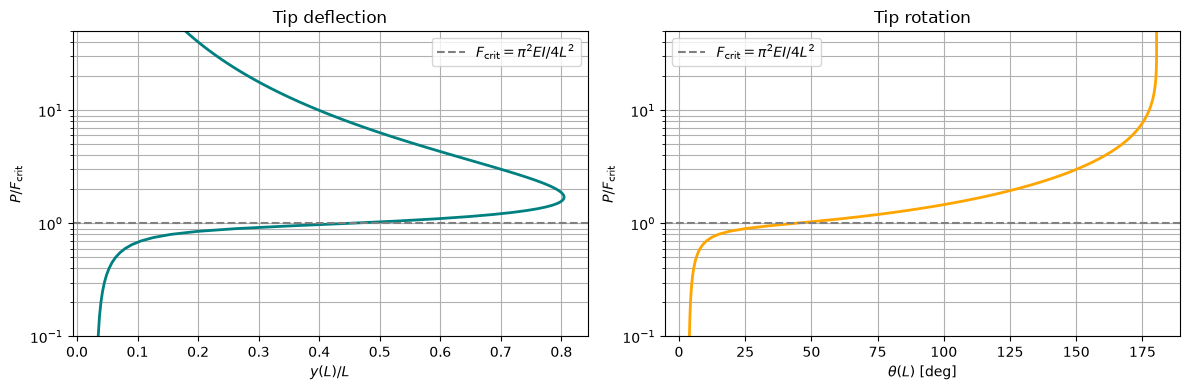

In [9]:
# Bifurcation diagram: load on the vertical axis
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(np.array(tip_deflections) / L, compression_values / F_crit, lw=2, color="teal")
ax[0].set_title("Tip deflection")
ax[0].set_xlabel("$y(L) / L$")

ax[1].plot(np.rad2deg(tip_rotations), compression_values / F_crit, lw=2, color="orange")
ax[1].set_title("Tip rotation")
ax[1].set_xlabel(r"$\theta(L)$ [deg]")

for a in ax:
    a.axhline(1.0, color="gray", ls="--", label=r"$F_{\mathrm{crit}} = \pi^2 EI / 4L^2$")
    a.set_ylabel(r"$P / F_{\mathrm{crit}}$")
    a.set_yscale("log")
    a.set_ylim(0.1, compression_values[-1] / F_crit)
    a.legend()
    a.grid(True, which="both")
plt.tight_layout()
plt.show()

### Boundary layer at large loads

For $P \gg F_{\text{crit}}$ the beam folds back. Away from the clamp it is nearly aligned with the load, $\theta \approx \pi$, and the bending concentrates near $s = 0$ in a layer of width
$$
\ell = \sqrt{\frac{EI}{P}} .
$$
With $F_x = -P$ and $F_y = 0$, the Euler-Lagrange equation of the energy is $EI\,\theta''(s) = -P\sin\theta(s)$. In the variable $s/\ell$ it is the pendulum equation. For $\ell \ll L$ and a negligible imperfection, the conditions are $\theta(0) = 0$ and $\theta \to \pi$ far from the clamp, and the solution is the separatrix
$$
\theta(s) = \pi - 4\arctan\big(e^{-s/\ell}\big),
$$
whose curvature is $\theta'(s) = (2/\ell)\,\mathrm{sech}(s/\ell)$. The curvature at the clamp, $\theta'(0) = 2\sqrt{P/EI}$, grows without bound with the load.

The plot below shows the computed angle against $s/\ell$: the profiles collapse on the separatrix as $L/\ell = \sqrt{PL^2/EI}$ increases.

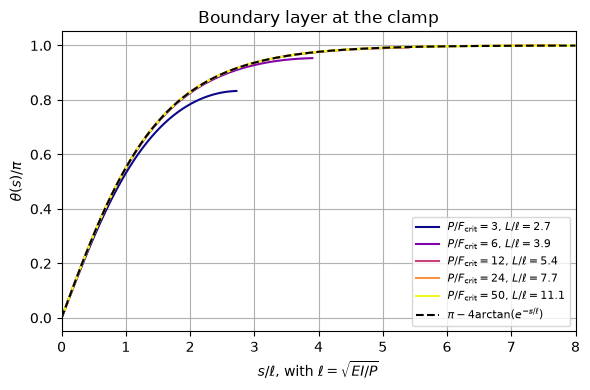

In [10]:
sigma = np.linspace(0, 8, 200)

fig, ax = plt.subplots(figsize=(6, 4))
norm = mcolors.LogNorm(vmin=3, vmax=compression_values[-1] / F_crit)
for P_ratio in [3, 6, 12, 25, 50]:
    i = np.argmin(abs(compression_values / F_crit - P_ratio))
    P = compression_values[i]
    ell = np.sqrt(EI / P)
    ax.plot(s_nodes / ell, theta_profiles[i] / np.pi, color=cm.plasma(norm(P / F_crit)),
            label=f"$P/F_{{\\mathrm{{crit}}}} = {P / F_crit:.0f}$, $L/\\ell = {L / ell:.1f}$")
ax.plot(sigma, 1 - 4 * np.arctan(np.exp(-sigma)) / np.pi, "k--", label=r"$\pi - 4\arctan(e^{-s/\ell})$")
ax.set_xlim(0, 8)
ax.set_xlabel(r"$s / \ell$, with $\ell = \sqrt{EI/P}$")
ax.set_ylabel(r"$\theta(s) / \pi$")
ax.set_title("Boundary layer at the clamp")
ax.legend(fontsize=8)
ax.grid(True)
plt.tight_layout()
plt.show()

# Exercise

Consider an initially vertical beam clamped at the bottom and free at the top, loaded by its own weight (a distributed force).
- Write the potential energy of the weight as a functional of $\theta$, modify the energy above, and compute the critical load for buckling with the nonlinear elastica model.
- Design a simple experiment to measure the critical length at which a beam buckles under its own weight, for example with a strip of thick paper.

Solve the problem in dimensionless form: the critical value of the dimensionless loading parameter then gives the critical length observed in the experiment.